### Exercise for all the things we've done before

#### 1. Data
- Got the data
  - generate the data using `torch.normal(mean, std, size, generator=None, out=None)`
- split the data into train/test sets

#### 2. Build the Model
- initialize the weights and bias randomly
  - `nn.Parameter()`
  - `torch.randn(*size, *, generator=None, out=None, dtype=None, device=None, requires_grad=False)`
- core: **forward pass function**
  - **`def forward(self, x):`**
- architecture

#### 3. Decide loss function and optimizer
- loss function
- optimizer:
  - `class torch.optim.Optimizer(params, defaults)`

#### 4. Training loop and test loop
- forward pass
    - `train_pred = model(x_train)`
- calculate the loss
    - `train_loss = loss_fn(train_pred, train_y)`
- back propagation
    - `optimizer.zero_grad()`
    - `train_loss.backward()`
- update weights
    - `optimizer.step()`

#### 5. Check the train/test result to optimize the hyperparameters

#### 6. Save/Load the model

Check the state of the model:
- `model.state_dict()`
- `optimizer.state_dict()`

In [128]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn as nn

In [139]:
# generate the data

w_true = torch.tensor([1.0,-2.0,3.0]).reshape(-1,1)
b_true = torch.tensor([-4.0])
nums = 500 # nums of data

def synthetic_data(w,b,nums):
    
    data_x=torch.normal(mean=0,std=1,size=(nums,len(w_true)))
    data_y=torch.mm(data_x, w_true) + b_true

    noise=torch.normal(mean=0,std=0.05,size=(nums,1))
    data_y+=noise

    train_num=int(0.8*nums)

    x_train=data_x[:train_num,]
    y_train=data_y[:train_num,]

    x_test=data_x[train_num:,]
    y_test=data_y[train_num:,]

    return x_train,y_train,x_test,y_test

x_train,y_train,x_test,y_test=synthetic_data(w_true,b_true,nums)

In [140]:
# Build the model

class LinearModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.rand(3,1))
        self.bias=nn.Parameter(torch.rand(1,dtype=torch.float,requires_grad=True))

    def forward(self,x:torch.Tensor) ->torch.Tensor:
        return torch.mm(x,self.weights)+self.bias
        

model=LinearModel()


# decide loss function and optimizer
loss_fn=nn.MSELoss()

optimizer=torch.optim.SGD(
    params=model.parameters(),
    lr=0.01,
)




In [141]:
train_loss_values=[]
test_loss_values=[]
epoch_count=[]


def training_testing_loop(epochs):
    
    for epoch in range(epochs):
        
        epoch_count.append(epoch)
        
        model.train()   #set to train mode


        # forward pass:
        train_pred=model(x_train)
        
        # calcute the loss
        train_loss = loss_fn(train_pred,y_train)
        train_loss_values.append(train_loss.item())
    
        #back propagation
        # set to grad_zero
        optimizer.zero_grad()
    
        # compute the grad
        train_loss.backward()
    
        #update weights
        optimizer.step()
    
        #set to test mode
        model.eval()
        
        with torch.inference_mode():
            
            test_pred=model(x_test)
            test_loss=loss_fn(test_pred,y_test)
    
            test_loss_values.append(test_loss.item())

            if epoch % 20 == 0:
                print(f"Epoch {epoch:3d} | Train Loss: {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}")
    
    

In [142]:
training_testing_loop(200)

Epoch   0 | Train Loss: 31.581694 | Test Loss: 33.846397
Epoch  20 | Train Loss: 14.452204 | Test Loss: 15.421642
Epoch  40 | Train Loss: 6.666884 | Test Loss: 7.083528
Epoch  60 | Train Loss: 3.099731 | Test Loss: 3.280058
Epoch  80 | Train Loss: 1.452411 | Test Loss: 1.531326
Epoch 100 | Train Loss: 0.685918 | Test Loss: 0.721018
Epoch 120 | Train Loss: 0.326708 | Test Loss: 0.342670
Epoch 140 | Train Loss: 0.157232 | Test Loss: 0.164694
Epoch 160 | Train Loss: 0.076771 | Test Loss: 0.080364
Epoch 180 | Train Loss: 0.038350 | Test Loss: 0.040122


In [143]:
model.state_dict(),w_true

(OrderedDict([('weights',
               tensor([[ 1.0358],
                       [-1.9539],
                       [ 2.9283]])),
              ('bias', tensor([-3.8953]))]),
 tensor([[ 1.],
         [-2.],
         [ 3.]]))

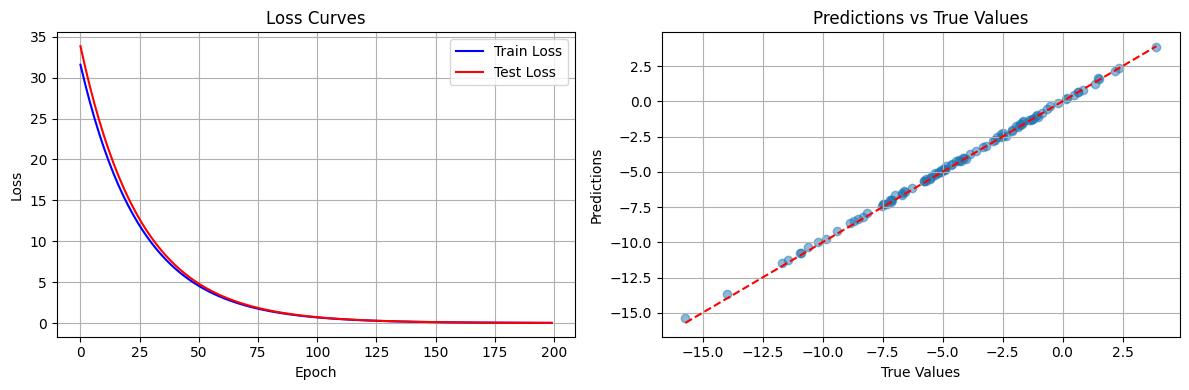


FINAL RESULTS
True weights:   [1.0, -2.0, 3.0]
Learned weights: [1.0357944965362549, -1.9539088010787964, 2.928323745727539]
True bias:      -4.0000
Learned bias:    -3.8953


In [144]:
plt.figure(figsize=(12, 4))

# Left plot - Loss curves
plt.subplot(1, 2, 1)
plt.plot(epoch_count, train_loss_values, 'b-', label='Train Loss')
plt.plot(epoch_count, test_loss_values, 'r-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# Right plot - Predictions
plt.subplot(1, 2, 2)
with torch.inference_mode():
    predictions = model(x_test)
plt.scatter(y_test.numpy(), predictions.numpy(), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs True Values')
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# RESULTS
# ============================================================
print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"True weights:   {w_true.flatten().tolist()}")
print(f"Learned weights: {model.weights.flatten().tolist()}")
print(f"True bias:      {b_true.item():.4f}")
print(f"Learned bias:    {model.bias.item():.4f}")

###  **Use pytorch linear function**
`class torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)`
- in_features (int) – size of each input sample

In [163]:
import torch
import torch.nn as nn

# ============================================================
# 1. CREATE DEVICE VARIABLE (ADD THIS)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# 2. DATA (no change)
# ============================================================
w_true = torch.tensor([1.0, -2, 3, 4.0]).reshape(-1, 1)
b_true = torch.tensor([-0.66])
nums = 1000

def synthetic_data(w, b, nums):
    data_x = torch.normal(mean=0, std=1, size=(nums, len(w_true)))
    data_y = torch.mm(data_x, w_true) + b_true
    noise = torch.normal(mean=0, std=0.05, size=(nums, 1))
    data_y += noise
    train_num = int(0.8 * nums)
    return data_x[:train_num], data_y[:train_num], data_x[train_num:], data_y[train_num:]

x_train, y_train, x_test, y_test = synthetic_data(w_true, b_true, nums)

# ============================================================
# 3. MOVE DATA TO GPU (ADD THIS)
# ============================================================
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

# ============================================================
# 4. MODEL
# ============================================================
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(
            in_features=len(w_true),
            out_features=1,
            bias=True,
        )

    def forward(self, x):
        return self.linear(x)

modelv2 = LinearRegressionModelV2()

# ============================================================
# 5. MOVE MODEL TO GPU (ADD THIS)
# ============================================================
modelv2 = modelv2.to(device)

# ============================================================
# 6. LOSS AND OPTIMIZER (no change)
# ============================================================
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(
    params=modelv2.parameters(),
    lr=0.01,
    momentum=0.5
)

# ============================================================
# 7. TRAINING (no change - everything already on GPU)
# ============================================================
epochs_v2 = 500
train_losses = []
test_losses = []

for epoch in range(epochs_v2):
    modelv2.train()
    
    y_pred = modelv2(x_train)
    train_loss = loss_fn(y_pred, y_train)
    train_losses.append(train_loss.item())
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    modelv2.eval()
    with torch.inference_mode():
        y_test_pred = modelv2(x_test)
        test_loss = loss_fn(y_test_pred, y_test)
        test_losses.append(test_loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_loss.item():.4f}, Test Loss = {test_loss.item():.4f}")

# ============================================================
# 8. RESULTS (move back to CPU for printing)
# ============================================================
print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"Learned weights: {modelv2.linear.weight.cpu().flatten().tolist()}")
print(f"Learned bias: {modelv2.linear.bias.cpu().item():.4f}")

Using device: cuda
Epoch 0: Train Loss = 4.7066, Test Loss = 4.7148
Epoch 10: Train Loss = 4.5856, Test Loss = 4.5865
Epoch 20: Train Loss = 4.4513, Test Loss = 4.4515
Epoch 30: Train Loss = 4.3169, Test Loss = 4.3165
Epoch 40: Train Loss = 4.1825, Test Loss = 4.1815
Epoch 50: Train Loss = 4.0482, Test Loss = 4.0465
Epoch 60: Train Loss = 3.9139, Test Loss = 3.9116
Epoch 70: Train Loss = 3.7795, Test Loss = 3.7766
Epoch 80: Train Loss = 3.6452, Test Loss = 3.6417
Epoch 90: Train Loss = 3.5109, Test Loss = 3.5068
Epoch 100: Train Loss = 3.3766, Test Loss = 3.3718
Epoch 110: Train Loss = 3.2423, Test Loss = 3.2369
Epoch 120: Train Loss = 3.1081, Test Loss = 3.1020
Epoch 130: Train Loss = 2.9738, Test Loss = 2.9672
Epoch 140: Train Loss = 2.8397, Test Loss = 2.8325
Epoch 150: Train Loss = 2.7055, Test Loss = 2.6980
Epoch 160: Train Loss = 2.5714, Test Loss = 2.5634
Epoch 170: Train Loss = 2.4373, Test Loss = 2.4289
Epoch 180: Train Loss = 2.3033, Test Loss = 2.2943
Epoch 190: Train Loss =

4